![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

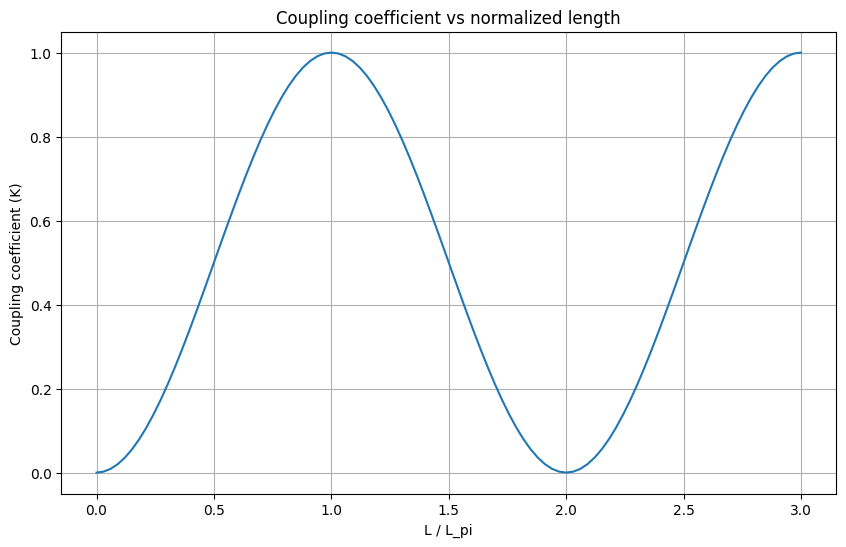

L_pi = 94.03 µm
Para completa transferencia (K=1): L = L_pi = 94.03 µm
Para división  de potencia 50/50 (K=0.5): L = L_pi/2 = 47.01 µm


In [6]:
# Plot the transfer function: K vs L/L_pi
L_values = np.linspace(0, 3*L_pi, 100)
K_values = (np.sin(1/2 * np.pi * (L_values/L_pi)))**2


plt.figure(figsize=(10, 6))
plt.plot(L_values/L_pi, K_values)
plt.xlabel('L / L_pi')
plt.ylabel('Coupling coefficient (K)')
plt.title('Coupling coefficient vs normalized length')
plt.grid()
plt.show()

print(f"L_pi = {L_pi:.2f} µm")
print(f"Para completa transferencia (K=1): L = L_pi = {L_pi:.2f} µm")
print(f"Para división  de potencia 50/50 (K=0.5): L = L_pi/2 = {L_pi/2:.2f} µm")

Por tanto, para obtener una transferencia completa de energía entre guías de onda, se necesitará una longitud (L) igual a la longitud de batido (L_pi). Por otra parte, para obtener una división de la potencia a la mitad se necesita una longitud (L) de la mitad de la longitud de batido (L_pi).

## LO.2. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [4]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.0274260517713  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


En la celda anterior se han calculado los modos y se ha obtenido el valor de L_pi

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


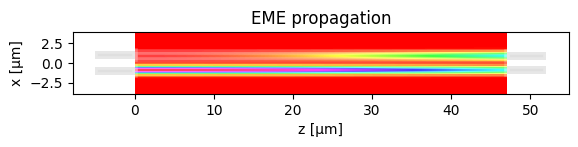

In [7]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2 # Number of input waveguides. For a 2x2 DC, we have 2 input waveguides and 2 output waveguides.
m.n_OUT = 2 # Number of output waveguides.

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Gráfica de valores

In [8]:
wg_gap = np.linspace(0.6, 1.6, 11) # Gap between waveguides
L_pi_values = np.zeros(len(wg_gap))

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605178396  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


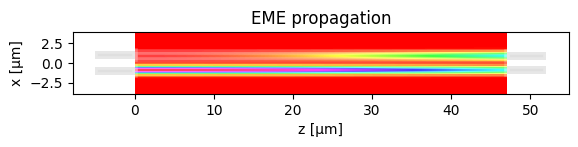

In [9]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

i = 0 # Index for the first gap value

wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap[i]
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap[i] # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
L_pi_values[i] = L_pi

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  128.065673339184  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1281 [00:00<?, ?it/s]

------- Pameters -------
MMI length 64.0328
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9841
Total OUT power: 0.9737
Excess loss [dB] =  0.1157
------------------------
Power over OUTs:  ['0.4869', '0.4868']
Ratio over OUTs ['0.5000', '0.5000']


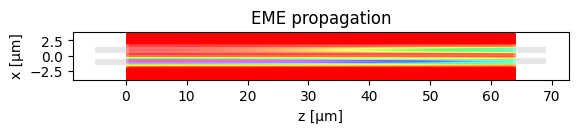

In [10]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

i = 1 # Index for the second gap value

wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap[i]
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap[i] # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
L_pi_values[i] = L_pi

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  173.96389977144426  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1740 [00:00<?, ?it/s]

------- Pameters -------
MMI length 86.9819
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9882
Total OUT power: 0.9778
Excess loss [dB] =  0.0976
------------------------
Power over OUTs:  ['0.4888', '0.4890']
Ratio over OUTs ['0.4999', '0.5001']


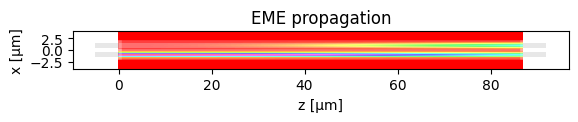

In [11]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

i = 2 

wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap[i]
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap[i] # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
L_pi_values[i] = L_pi

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  235.77407047782813  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2358 [00:00<?, ?it/s]

------- Pameters -------
MMI length 117.8870
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9832
Total OUT power: 0.9728
Excess loss [dB] =  0.1198
------------------------
Power over OUTs:  ['0.4863', '0.4865']
Ratio over OUTs ['0.4999', '0.5001']


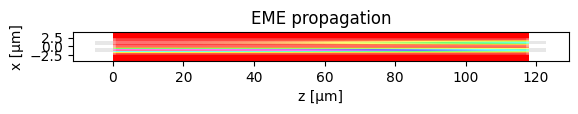

In [12]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

i = 3

wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap[i]
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap[i] # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
L_pi_values[i] = L_pi

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  318.884152076578  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3189 [00:00<?, ?it/s]

------- Pameters -------
MMI length 159.4421
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9663
Total OUT power: 0.9560
Excess loss [dB] =  0.1955
------------------------
Power over OUTs:  ['0.4778', '0.4782']
Ratio over OUTs ['0.4998', '0.5002']


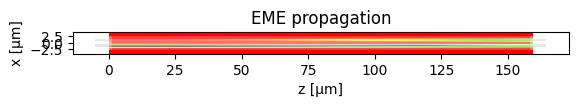

In [13]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

i = 4

wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap[i]
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap[i] # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
L_pi_values[i] = L_pi

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  430.5476100767555  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4305 [00:00<?, ?it/s]

------- Pameters -------
MMI length 215.2738
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9360
Total OUT power: 0.9258
Excess loss [dB] =  0.3351
------------------------
Power over OUTs:  ['0.4628', '0.4629']
Ratio over OUTs ['0.4999', '0.5001']


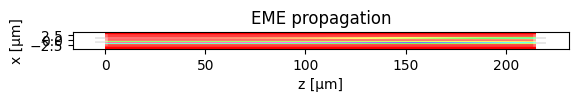

In [21]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

i = 5

wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap[i]
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap[i] # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
L_pi_values[i] = L_pi

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  580.4271049532105  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2136
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8914
Total OUT power: 0.8817
Excess loss [dB] =  0.5470
------------------------
Power over OUTs:  ['0.4407', '0.4409']
Ratio over OUTs ['0.4999', '0.5001']


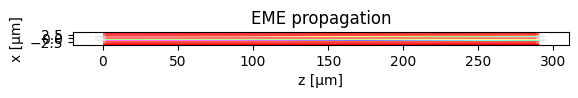

In [23]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

i = 6

wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap[i]
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap[i] # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
L_pi_values[i] = L_pi

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  781.390139174281  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/7814 [00:00<?, ?it/s]

------- Pameters -------
MMI length 390.6951
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8474
Total OUT power: 0.8380
Excess loss [dB] =  0.7677
------------------------
Power over OUTs:  ['0.4189', '0.4191']
Ratio over OUTs ['0.4999', '0.5001']


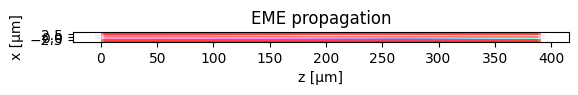

In [27]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

i = 7

wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap[i]
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap[i] # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
L_pi_values[i] = L_pi

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  1050.478684860597  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/10505 [00:00<?, ?it/s]

------- Pameters -------
MMI length 525.2393
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7870
Total OUT power: 0.7782
Excess loss [dB] =  1.0893
------------------------
Power over OUTs:  ['0.3889', '0.3893']
Ratio over OUTs ['0.4997', '0.5003']


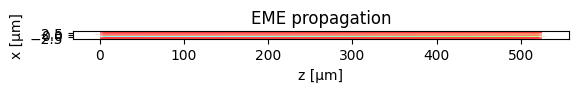

In [29]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

i = 8

wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap[i]
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap[i] # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
L_pi_values[i] = L_pi

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  1410.660712373114  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/14107 [00:00<?, ?it/s]

------- Pameters -------
MMI length 705.3304
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7299
Total OUT power: 0.7217
Excess loss [dB] =  1.4167
------------------------
Power over OUTs:  ['0.3607', '0.3609']
Ratio over OUTs ['0.4999', '0.5001']


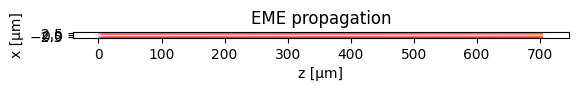

In [30]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

i = 9

wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap[i]
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap[i] # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
L_pi_values[i] = L_pi

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  1892.467412412244  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/18925 [00:00<?, ?it/s]

------- Pameters -------
MMI length 946.2337
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.6724
Total OUT power: 0.6648
Excess loss [dB] =  1.7729
------------------------
Power over OUTs:  ['0.3327', '0.3321']
Ratio over OUTs ['0.5004', '0.4996']


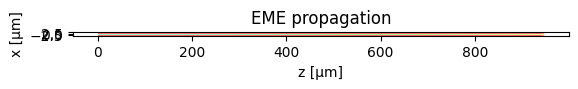

In [ ]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

i = 10

wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap[i]
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap[i] # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = np.abs(m.get_L_pi())
print("L_pi = ", L_pi, " µm")
L_pi_values[i] = L_pi

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

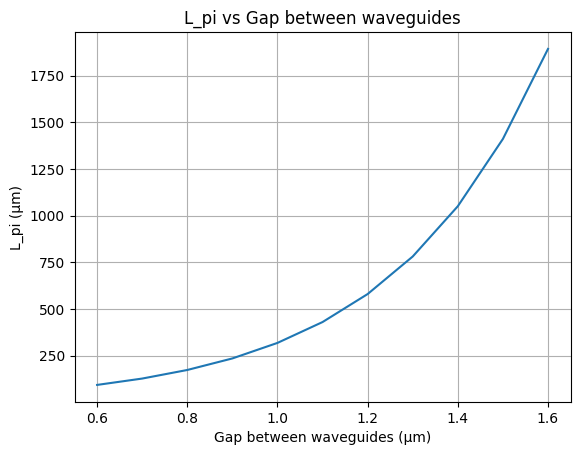

In [31]:
plt.plot(wg_gap, L_pi_values)
plt.xlabel("Gap between waveguides (µm)")
plt.ylabel("L_pi (µm)")
plt.title("L_pi vs Gap between waveguides")
plt.grid()
plt.show()

## LO.3. Parallel uncoupled waveguides

Qué distancia es necesaria par obtener un coeficiente de acoplamiento de 0.1

Despejar L_pi de la ecuación del coeficiente de acoplamiento



In [7]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.1
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 

L = 10e4

L_pi = L * np.pi / (2*np.arcsin(np.sqrt(0.1)))

print(f'L_pi = {L_pi:.2f} µm')


L_pi = 488203.15 µm


### Para deep waveguides

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i],

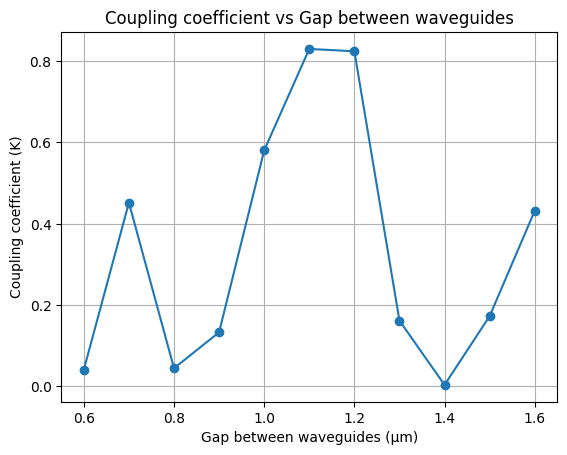

In [6]:
L = 1e4
wg_width = 1

wg_gap = np.linspace(0.6, 1.6, 11) # Gap between waveguides
L_pi_values = []
K_values = []

for gap in wg_gap:

    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = 2
    m.find_all_modes()

    L_pi = m.get_L_pi()
    L_pi_values.append(L_pi)
    
    K_values.append(np.sin(1/2 * np.pi * (L/L_pi))**2)

plt.plot(wg_gap, K_values, 'o-')
plt.xlabel("Gap between waveguides (µm)")
plt.ylabel("Coupling coefficient (K)")
plt.title("Coupling coefficient vs Gap between waveguides")
plt.grid()
plt.show()

### Para shallow waveguides

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i],

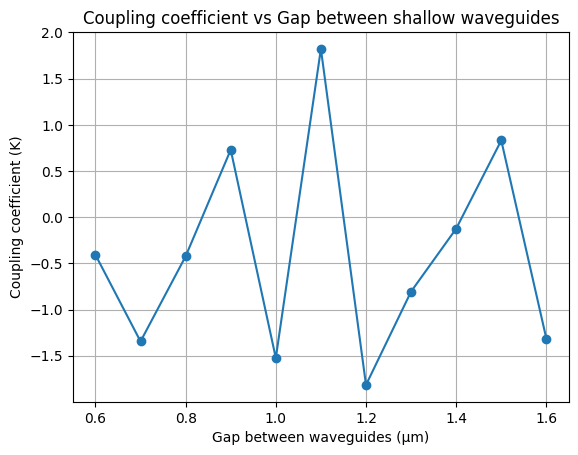

In [7]:
L = 1e4
wg_width = 1
sh_width = 0.5

wg_gap = np.linspace(0.6, 1.6, 11) # Gap between waveguides
L_pi_values = []
K_values = []

for gap in wg_gap:

    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = gap
    m.DC_wg_width = wg_width
    m.DC_slab_thickness = sh_width   # <<< aquí se introduce el slab
    m.DC_N_waveguides = 2
    m.find_all_modes()

    L_pi = np.abs(m.get_L_pi())
    L_pi_values.append(L_pi)
    
    K_values.append((np.sin(1/2 * np.pi * (L/L_pi)))*2)

plt.plot(wg_gap, K_values, 'o-')
plt.xlabel("Gap between waveguides (µm)")
plt.ylabel("Coupling coefficient (K)")
plt.title("Coupling coefficient vs Gap between shallow waveguides")
plt.grid()
plt.show()

## LO.4. 2x2 Multimode Interference Coupler

### LO.4.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

Interferencia pareada y interferencia simétrica

La interferencia pareada se ubica las entradas tal que al intentar propagar un modo, para los modos impares la parte positiva y negativa se cancela, mientras que para los modos pares hay una interferencia constructiva. Para el caso de la pareada, la posición de las entradas tiene que estar a +- el ancho efectivo entre 6. La imagen con dos salidas aparecerá a una distancia de L_pi/2.

In [8]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. If the amount of modes is too low, the propagation will not be accurate and there will be some power loss.

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255049  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


In [9]:
# Distancia para obterer una imagen con dos salidas

print(f"Distancia para obtener una imagen con dos salidas = {L_pi/2:.2f} µm")

Distancia para obtener una imagen con dos salidas = 34.52 µm


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


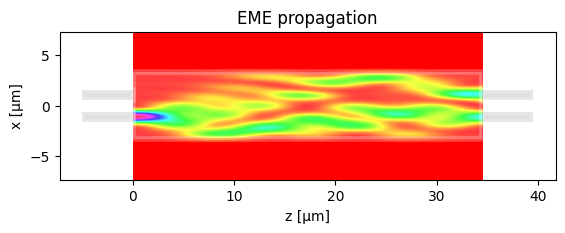

In [10]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width * np.array([-1/6, 1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width * np.array([-1/6, 1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi/2 # STUDENT

# Run propagation
m.propagation()

### LO.4.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.1000
------------------------
Total power IN coupled 0.9647
Total OUT power: 0.9155
Excess loss [dB] =  0.3836
------------------------
Power over OUTs:  ['0.4712', '0.4443']
Ratio over OUTs ['0.5147', '0.4853']


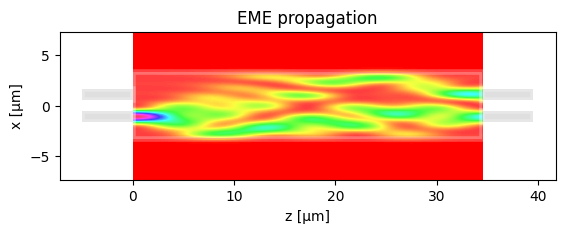

In [ ]:
dy = 0.0 # Vertical offset in the waveguide positions to see how it affects the coupling.
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width * np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width * np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = 0 # STUDENT 

# Run propagation
m.propagation()


 Probando dL_MMI = -0.6 | dy = -0.025 ---


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/678 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.6000
IO wg width 1.0000
IO wg width increment 0.1000
------------------------
Total power IN coupled 0.9666
Total OUT power: 0.9022
Excess loss [dB] =  0.4469
------------------------
Power over OUTs:  ['0.4590', '0.4432']
Ratio over OUTs ['0.5088', '0.4912']

 Probando dL_MMI = -0.6 | dy = -0.5 ---


  0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/682 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 0.1000
------------------------
Total power IN coupled 0.9636
Total OUT power: 0.9211
Excess loss [dB] =  0.3570
------------------------
Power over OUTs:  ['0.4688', '0.4523']
Ratio over OUTs ['0.5090', '0.4910']

 Probando dL_MMI = -0.4 | dy = 0.05 ---


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/682 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 0.1000
------------------------
Total power IN coupled 0.9615
Total OUT power: 0.9241
Excess loss [dB] =  0.3429
------------------------
Power over OUTs:  ['0.4695', '0.4546']
Ratio over OUTs ['0.5081', '0.4919']


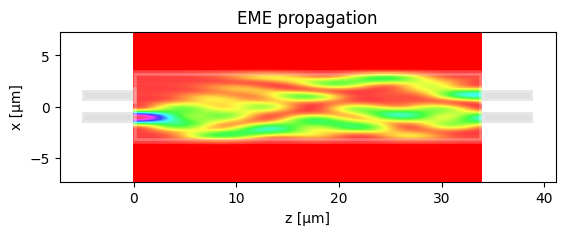

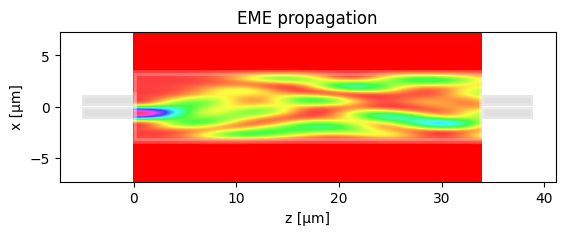

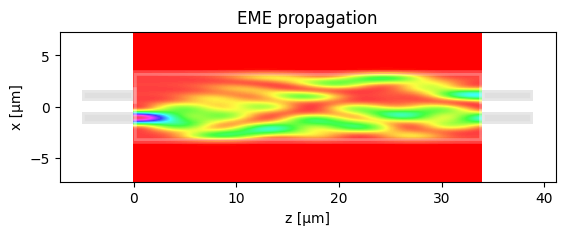

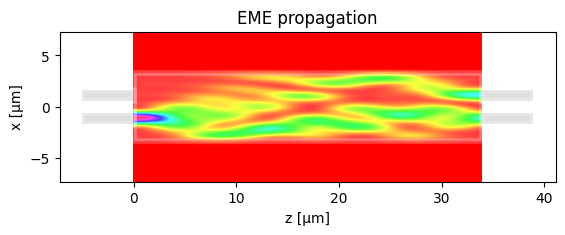

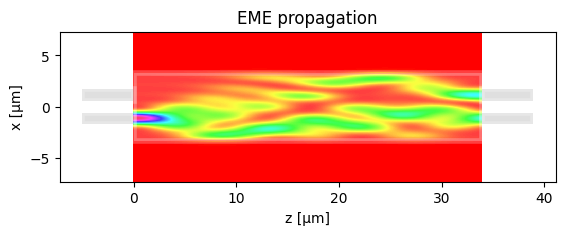

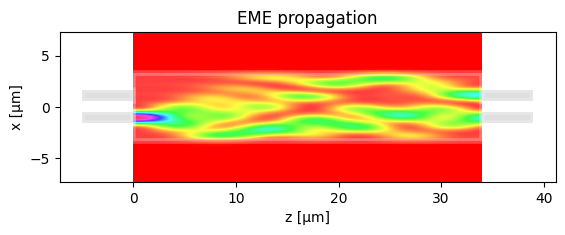

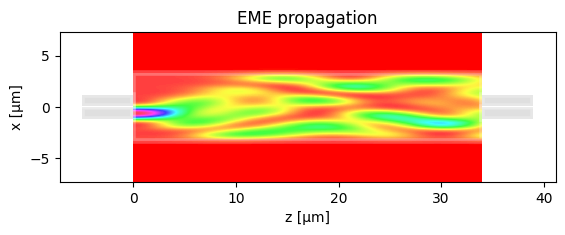

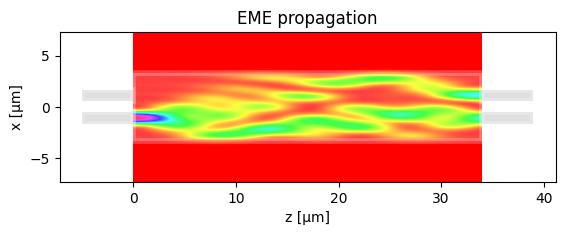

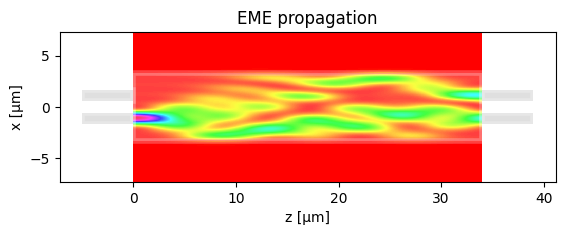

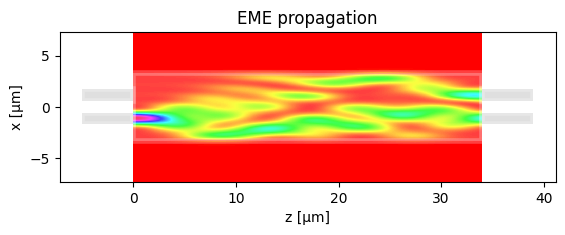

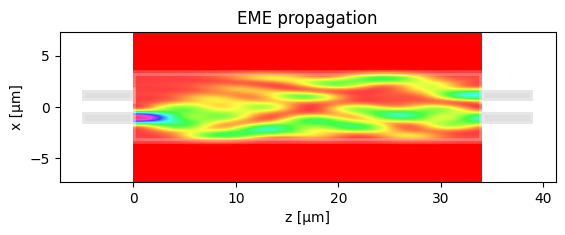

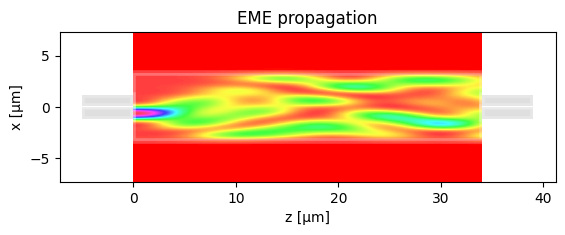

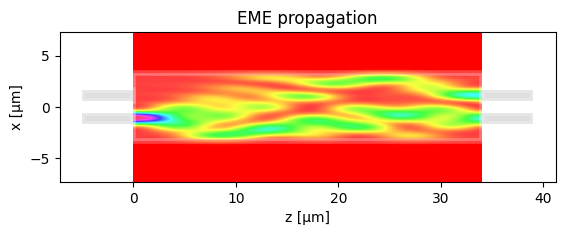

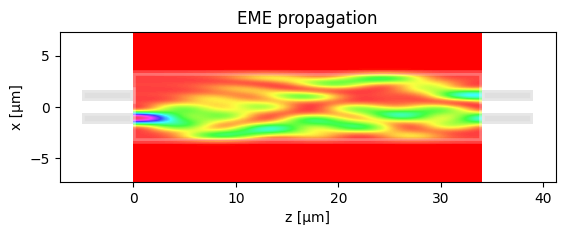

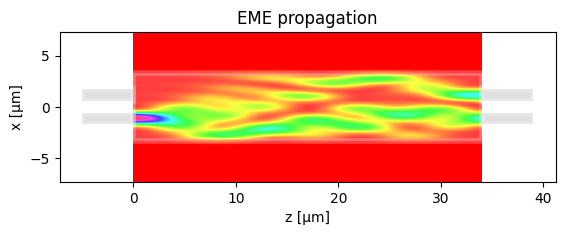

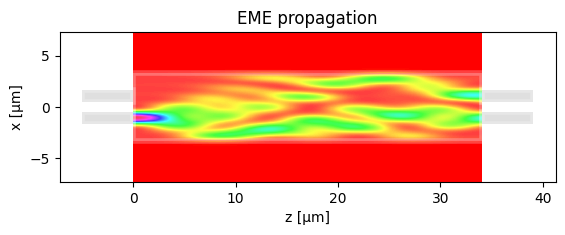

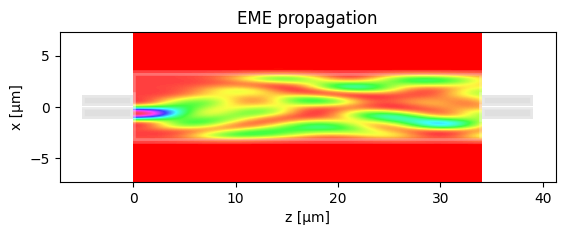

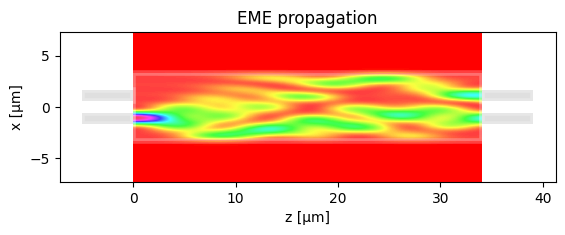

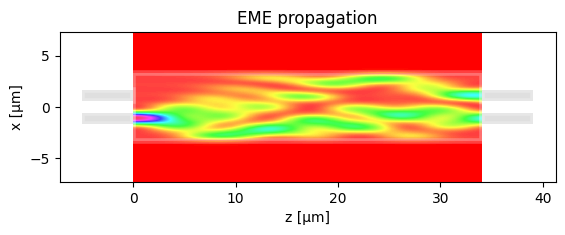

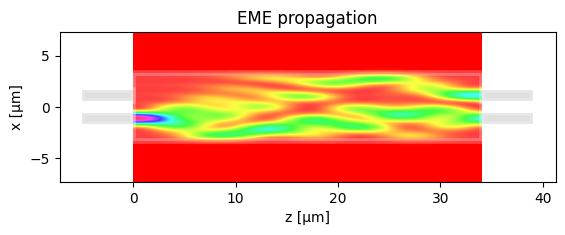

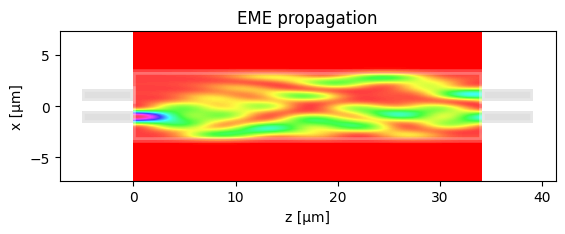

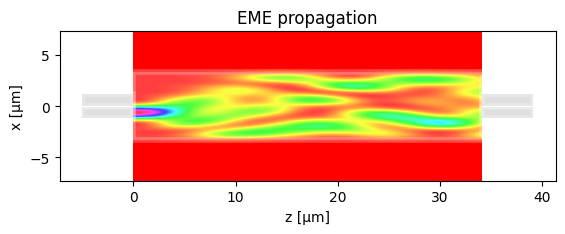

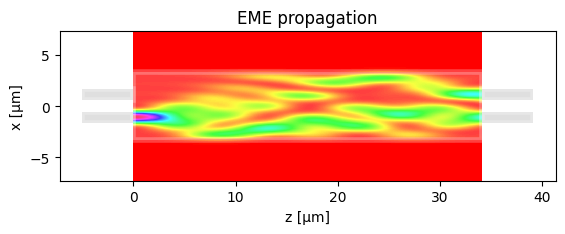

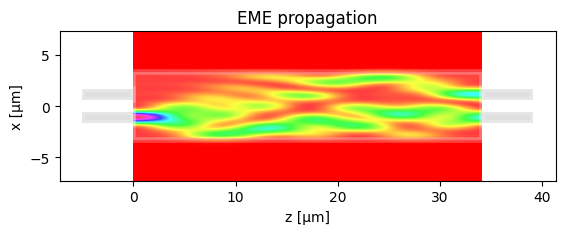

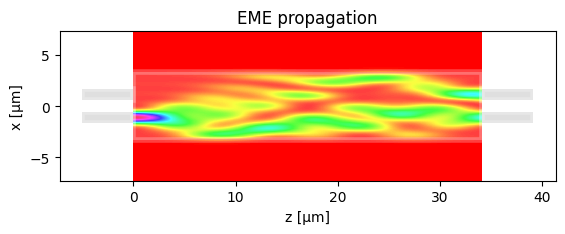

In [14]:
d_lengths = [-0.6, -0.55, -0.5, -0.45, -0.4]
d_positions = [-0.025, -0.5, 0.0, 0.025, 0.05]

for dl in d_lengths:
    for dy in d_positions:
        print(f"\n Probando dL_MMI = {dl} | dy = {dy} ---")

        # MMI I/O waveguide positions (check class slides for type of MMI)
        m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT
        m.OUT_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT

        # MMI length (check class slides for type of MMI)
        m.dL_MMI = dl
        
        # Run propagation
        m.propagation()

### LO.4.3 2x2 Multimode Interference Coupler – Optimization (II)

In [11]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.1 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607256278  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/670 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 0.1000
------------------------
Total power IN coupled 0.9647
Total OUT power: 0.9005
Excess loss [dB] =  0.4550
------------------------
Power over OUTs:  ['0.4522', '0.4483']
Ratio over OUTs ['0.5022', '0.4978']


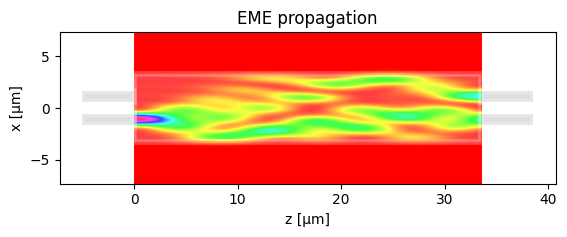

In [12]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.0
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width * np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width * np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi/2  # STUDENT
m.dL_MMI = -1 # STUDENT

# Run propagation
m.propagation()


--- Incremento de ancho I/O wg_width_dw = 0.6 um ---


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/682 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 0.6000
------------------------
Total power IN coupled 0.9894
Total OUT power: 0.9780
Excess loss [dB] =  0.0964
------------------------
Power over OUTs:  ['0.4982', '0.4798']
Ratio over OUTs ['0.5094', '0.4906']

--- Incremento de ancho I/O wg_width_dw = 0.7 um ---


...

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 1.3000
------------------------
Total power IN coupled 0.9997
Total OUT power: 1.0008
Excess loss [dB] =  -0.0034
------------------------
Power over OUTs:  ['0.5113', '0.4895']
Ratio over OUTs ['0.5109', '0.4891']

--- Incremento de ancho I/O wg_width_dw = 1.4 um ---


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/682 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 1.4000
------------------------
Total power IN coupled 0.9998
Total OUT power: 1.0020
Excess loss [dB] =  -0.0087
------------------------
Power over OUTs:  ['0.5119', '0.4901']
Ratio over OUTs ['0.5109', '0.4891']


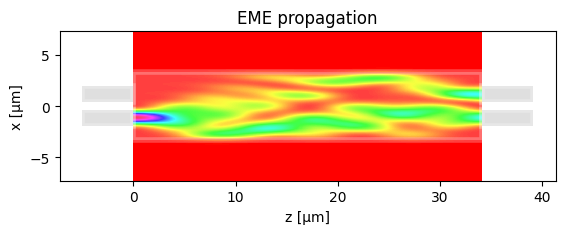

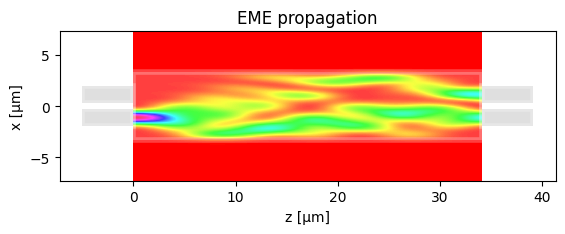

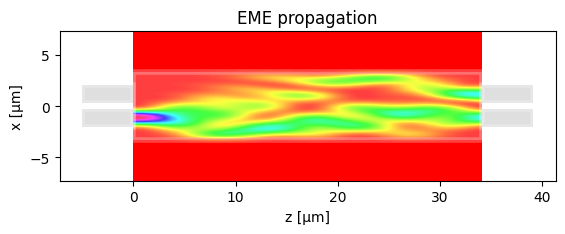

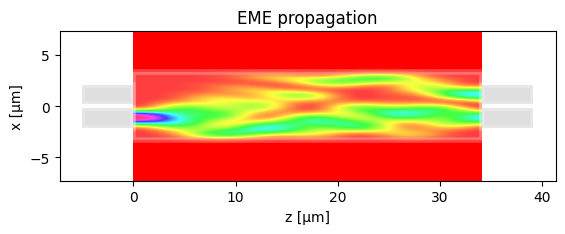

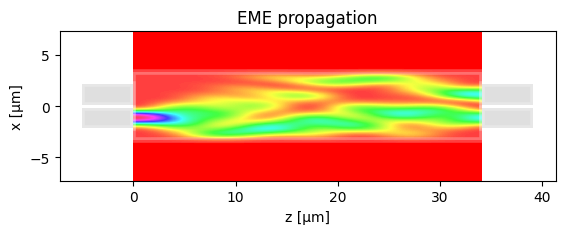

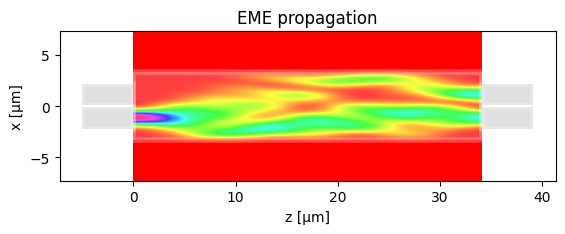

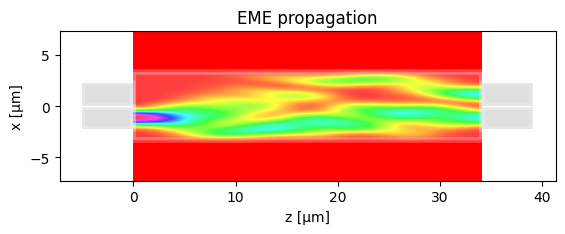

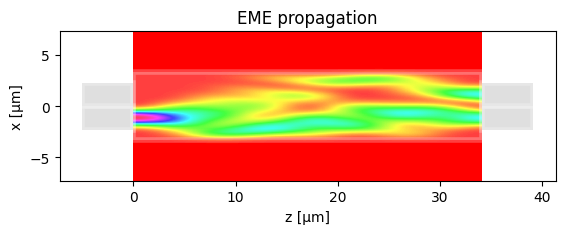

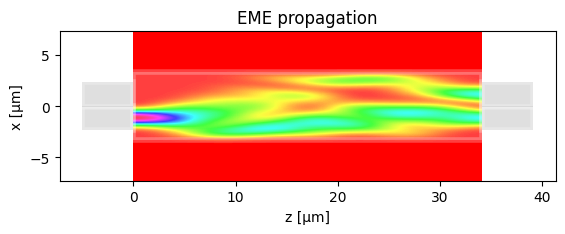

In [15]:
anchos_extra_a_probar = [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]
mmi_Width = 6.6

for dw in anchos_extra_a_probar:
    print(f"\n--- Incremento de ancho I/O wg_width_dw = {dw} um ---")
    
    m = MMI_EME()
    m.MMI_width = mmi_Width
    m.wg_width_dw = dw
    
    m.find_all_modes()
    L_pi = m.get_L_pi()
    
    m.n_IN = 2
    m.n_OUT = 2
    
    dy = 0.05
    m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy, dy])
    m.OUT_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy, dy])
    
    m.L_MMI = 1/2 * L_pi
    m.dL_MMI = -0.4
    
    m.propagation()

## LO.5. 1x4 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">


### Sin optimización

In [17]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 13.2

m = MMI_EME()
m.MMI_width = mmi_Width
m.MMI_num_modes = 30 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  263.95027837564874  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/990 [00:00<?, ?it/s]

------- Pameters -------
MMI length 49.4907
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9480
Total OUT power: 0.8297
Excess loss [dB] =  0.8108
------------------------
Power over OUTs:  ['0.2114', '0.2035', '0.2034', '0.2114']
Ratio over OUTs ['0.2548', '0.2453', '0.2452', '0.2548']


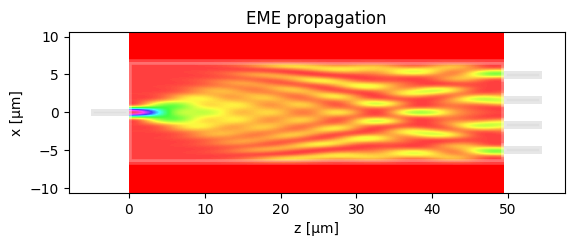

In [18]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  1 # STUDENT
m.n_OUT = 4 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([0])
m.OUT_WVG_positions = mmi_Width * np.array([ -3/8, -1/8, 1/8, 3/8])

# MMI length (check class slides for type of MMI)
m.L_MMI = 3*L_pi/16

# Run propagation
m.propagation()

### Primera optimización

In [19]:
mmi_Width = 13.2

m = MMI_EME()
m.MMI_width = mmi_Width
m.MMI_num_modes = 30 

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN =  1
m.n_OUT = 4

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  263.95027837544916  µm


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)



 Probando dL_MMI = -1.1 | dy = 0.07


  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/968 [00:00<?, ?it/s]

------- Pameters -------
MMI length 49.4907
MMI length increment -1.1000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9480
Total OUT power: 0.2426
Excess loss [dB] =  6.1517
------------------------
Power over OUTs:  ['0.0630', '0.0582', '0.0582', '0.0630']
Ratio over OUTs ['0.2599', '0.2401', '0.2401', '0.2599']


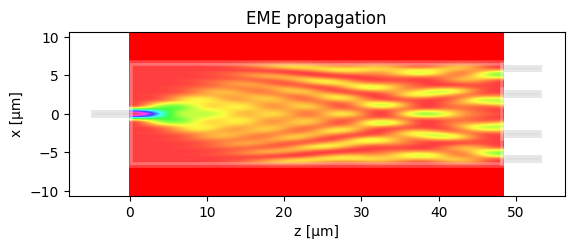

In [20]:
dl = -1.1
dy = 0.07

print(f"\n Probando dL_MMI = {dl} | dy = {dy}")

m.IN_WVG_positions = np.array([0])
m.OUT_WVG_positions = mmi_Width * np.array([-3/8, -1/8, 1/8, 3/8] + np.array([-dy,-dy, dy, dy]))

m.L_MMI = 3*L_pi/16
m.dL_MMI = dl

m.propagation()

### Segunda optimización

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  263.9502783752895  µm

 Probando dL_MMI = -1.1 | dy = 0.07 | dw = 1.5 ---


c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/968 [00:00<?, ?it/s]

------- Pameters -------
MMI length 49.4907
MMI length increment -1.1000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9480
Total OUT power: 0.1654
Excess loss [dB] =  7.8148
------------------------
Power over OUTs:  ['0.0346', '0.0481', '0.0481', '0.0346']
Ratio over OUTs ['0.2093', '0.2907', '0.2907', '0.2093']


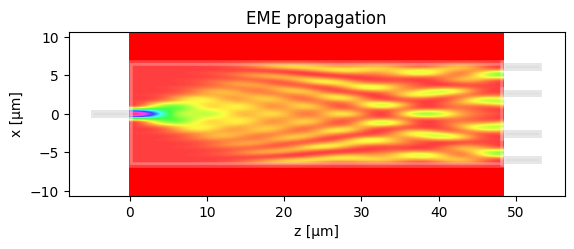

In [10]:
dl = -1.1
dy = 0.07 
dw = 1.5

mmi_Width = 13.2

m = MMI_EME()
m.MMI_width = mmi_Width
m.MMI_width_dw = dw
m.MMI_num_modes = 30 

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN =  1
m.n_OUT = 4 

print(f"\n Probando dL_MMI = {dl} | dy = {dy} | dw = {dw} ---")

m.IN_WVG_positions = np.array([0])
m.OUT_WVG_positions = (mmi_Width + 0.35) * np.array([-3/8, -1/8, 1/8, 3/8] + np.array([-dy,-dy, dy, dy]))

m.L_MMI = 3*L_pi/16
m.dL_MMI = dl

m.propagation()

## Extra - Exercises

Decir cuál es más tolerante a la variación de la longitud de onda, o cual es la diferencia entre anchos de guías de ondas o gaps.

### E1. Directional coupler gap dependence

In [ ]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

# STUDENT. Plot goes here


### E2. Directional coupler wavelength dependence

In [ ]:
wavelength = ... # STUDENT code goes here

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_neff = deep_dcoupler_cs.n_eff
L_pi_TE = ... # STUDENT code here

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Deep')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

### E3. MMI coupler wavelength dependence

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

### E4. MMI coupler body width dependence

In [ ]:
lambda_c = 1.55

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 